# การสร้างกราฟด้วยวิธีเชิงตัวเลขใน Python (numpy + matplotlib)

| หัวข้อ | รายละเอียด |
|---|---|
| วัตถุประสงค์ 1 | เข้าใจว่าคอมพิวเตอร์วาดกราฟจาก **คู่อันดับจำนวนจำกัด** $(x_i, y_i)$ ไม่ใช่จากฟังก์ชันต่อเนื่อง |
| วัตถุประสงค์ 2 | ใช้ `np.linspace` สร้างจุด และคำนวณ $y$ จากฟังก์ชันแบบ array |
| วัตถุประสงค์ 3 | เห็นผลของจำนวนจุด N ต่อรูปร่างกราฟ (N = 10, 20, 50) |
| วัตถุประสงค์ 4 | ปรับแต่งกราฟด้วย matplotlib ได้ (สี เส้น จุด ป้าย คำอธิบาย) |
| ความรู้พื้นฐาน | ตัวแปร, list, `for` loop ใน Python เบื้องต้น |

## แนวคิดหลัก

การวาดกราฟ $y = f(x)$ ด้วยคอมพิวเตอร์มี 3 ขั้นตอน

| ขั้น | สิ่งที่ทำ | คำสั่ง |
|---|---|---|
| 1. สุ่มตัวอย่าง (sampling) | เลือกค่า $x$ จำนวน N ค่า: $x_0, x_1, \dots, x_{N-1}$ | `x = np.linspace(a, b, N)` |
| 2. คำนวณ | หา $y_i = f(x_i)$ ทุกค่าพร้อมกัน | `y = np.sin(x)` |
| 3. วาด | นำคู่อันดับ $(x_i, y_i)$ มาวางแล้ว **ลากเส้นตรงเชื่อมจุดที่อยู่ติดกัน** | `plt.plot(x, y)` |

> ข้อสังเกต: สิ่งที่เราเห็นเป็น "เส้นโค้ง" แท้จริงคือ **เส้นตรงสั้น ๆ จำนวนมากต่อกัน**

## ส่วนที่ 1 — นำเข้าไลบรารี

In [ ]:
import numpy as np                 # คำนวณเชิงตัวเลขกับ array
import matplotlib.pyplot as plt    # วาดกราฟ

# ทำให้กราฟแสดงในโน้ตบุ๊ก
%matplotlib inline

## ส่วนที่ 2 — สร้างค่า x จำนวน 10 ค่า ในช่วง [0, 10]

`np.linspace(a, b, N)` สร้าง N ค่า เว้นระยะเท่ากัน **รวมจุดปลายทั้งสอง** ระยะห่างคือ

$$\Delta x = \frac{b - a}{N - 1}$$

In [ ]:
x = np.linspace(0, 10, 10)

print("x =", x)
print("จำนวนสมาชิก =", len(x))
print("Δx =", x[1] - x[0])

**คำถามชวนคิด:** ทำไม Δx จึงไม่เท่ากับ 1 ทั้งที่ช่วงยาว 10 และมี 10 จุด?

(คำใบ้: 10 จุด แบ่งช่วงออกเป็นกี่ "ช่องว่าง"?)

## ส่วนที่ 3 — คำนวณ y = sin(x)

numpy คำนวณ `np.sin(x)` กับ **ทุกสมาชิกของ array พร้อมกัน** ไม่ต้องเขียน loop

In [ ]:
y = np.sin(x)

# แสดงคู่อันดับ (x_i, y_i) เป็นตาราง
print(f"{'i':>3} {'x_i':>8} {'y_i = sin(x_i)':>16}")
print("-" * 29)
for i in range(len(x)):
    print(f"{i:>3} {x[i]:>8.3f} {y[i]:>16.4f}")

## ส่วนที่ 4 — นำคู่อันดับมาวางบนกราฟ

### 4.1 วาดเฉพาะจุด
รูปแบบ `'o'` = วาดจุดวงกลม **ไม่ลากเส้น** จะเห็นว่าข้อมูลจริง ๆ มีแค่ 10 จุดเท่านั้น

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(x, y, 'o')
plt.xlabel('x')
plt.ylabel('y')
plt.title('N = 10 : points only')
plt.grid(alpha=0.3)
plt.show()

### 4.2 วาดจุดและลากเส้นเชื่อม
รูปแบบ `'o-'` = จุดวงกลม + เส้นทึบเชื่อมจุดที่อยู่ติดกันตามลำดับใน array

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(x, y, 'o-')
plt.xlabel('x')
plt.ylabel('y')
plt.title('N = 10 : points joined by straight lines')
plt.grid(alpha=0.3)
plt.show()

**สังเกต:** กราฟยังเป็นเหลี่ยม ยอดคลื่นถูกตัด และไม่เหมือน $\sin x$ ที่เรารู้จัก

## ส่วนที่ 5 — เพิ่มเป็น 20 ค่า (ช่วงเดิม)

In [ ]:
x20 = np.linspace(0, 10, 20)
y20 = np.sin(x20)
print("Δx =", x20[1] - x20[0])

plt.figure(figsize=(7, 4))
plt.plot(x20, y20, 'o-')
plt.xlabel('x')
plt.ylabel('y')
plt.title('N = 20')
plt.grid(alpha=0.3)
plt.show()

## ส่วนที่ 6 — เพิ่มเป็น 50 ค่า (ช่วงเดิม)

In [ ]:
x50 = np.linspace(0, 10, 50)
y50 = np.sin(x50)
print("Δx =", x50[1] - x50[0])

plt.figure(figsize=(7, 4))
plt.plot(x50, y50, 'o-', markersize=4)
plt.xlabel('x')
plt.ylabel('y')
plt.title('N = 50')
plt.grid(alpha=0.3)
plt.show()

## ส่วนที่ 7 — เปรียบเทียบ N = 10, 20, 50 ในรูปเดียว

ใช้ `plt.subplots` แบ่งรูปเป็น 3 ช่อง และวาดเส้นอ้างอิงสีเทา (1000 จุด) ซ้อนไว้

In [ ]:
x_ref = np.linspace(0, 10, 1000)          # เส้นอ้างอิง (ก็ยังเป็นจุด! แต่ถี่มาก)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)

for ax, N in zip(axes, [10, 20, 50]):
    xN = np.linspace(0, 10, N)
    ax.plot(x_ref, np.sin(x_ref), color='lightgray', linewidth=3, label='reference')
    ax.plot(xN, np.sin(xN), 'o-', markersize=4, label=f'N = {N}')
    ax.set_title(f'N = {N},  Δx = {xN[1]-xN[0]:.3f}')
    ax.set_xlabel('x')
    ax.grid(alpha=0.3)
    ax.legend(loc='lower left')

axes[0].set_ylabel('y')
plt.tight_layout()
plt.show()

## ส่วนที่ 8 — ขยายดูใกล้ ๆ (zoom)

ขยายช่วง $1 \le x \le 3$ จะเห็นชัดว่า "เส้นโค้ง" คือเส้นตรงสั้น ๆ ต่อกัน

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(x_ref, np.sin(x_ref), color='lightgray', linewidth=4, label='reference')
plt.plot(x,   y,   'o-',  label='N = 10')
plt.plot(x50, y50, 's--', markersize=4, label='N = 50')
plt.xlim(1, 3)
plt.ylim(0.0, 1.1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Zoom: 1 ≤ x ≤ 3')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### สรุปผลการทดลอง

| N | Δx | ลักษณะกราฟ |
|---|---|---|
| 10 | 1.111 | เหลี่ยมชัดเจน ยอดคลื่นหาย |
| 20 | 0.526 | ใกล้เคียงขึ้น ยังเห็นมุม |
| 50 | 0.204 | ดูเรียบด้วยตาเปล่า |

**ข้อสรุป:** N มากขึ้น → Δx เล็กลง → เส้นตรงแต่ละช่วงสั้นลง → กราฟใกล้ฟังก์ชันจริงมากขึ้น

## ส่วนที่ 9 — ทดลองเอง

ฟังก์ชัน `plot_sampled(N)` วาด $\sin x$ ด้วย N จุด ลองเปลี่ยนค่าใน list แล้วรันซ้ำ

In [ ]:
def plot_sampled(N, a=0, b=10):
    xN = np.linspace(a, b, N)
    plt.plot(xN, np.sin(xN), 'o-', markersize=3, label=f'N = {N}')

plt.figure(figsize=(8, 4))
for N in [4, 7, 12, 100]:        # <-- ลองเปลี่ยนค่าตรงนี้
    plot_sampled(N)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## ส่วนที่ 10 — ตารางอ้างอิงคำสั่ง

### ฟังก์ชัน numpy ที่ใช้บ่อย

| คณิตศาสตร์ | numpy |
|---|---|
| $\sin x,\ \cos x,\ \tan x$ | `np.sin(x)`, `np.cos(x)`, `np.tan(x)` |
| $e^{x}$, $\ln x$ | `np.exp(x)`, `np.log(x)` |
| $\sqrt{x}$, $x^2$ | `np.sqrt(x)`, `x**2` |
| $\pi$ | `np.pi` |
| N จุดใน $[a,b]$ | `np.linspace(a, b, N)` |
| จาก $a$ ถึง (ไม่รวม) $b$ ทีละ $h$ | `np.arange(a, b, h)` |

### รูปแบบเส้นและจุด (format string เช่น `'ro--'`)

| สี | ความหมาย | จุด | ความหมาย | เส้น | ความหมาย |
|---|---|---|---|---|---|
| `'b'` | น้ำเงิน | `'o'` | วงกลม | `'-'` | ทึบ |
| `'r'` | แดง | `'s'` | สี่เหลี่ยม | `'--'` | ประ |
| `'g'` | เขียว | `'^'` | สามเหลี่ยม | `':'` | จุดไข่ปลา |
| `'k'` | ดำ | `'x'` | กากบาท | `'-.'` | ประสลับจุด |

### คำสั่งปรับแต่งกราฟ

| หน้าที่ | แบบ `plt.` (กราฟเดียว) | แบบ `ax.` (subplots) |
|---|---|---|
| ป้ายแกน | `plt.xlabel('x')` | `ax.set_xlabel('x')` |
| ชื่อกราฟ | `plt.title('...')` | `ax.set_title('...')` |
| ช่วงแกน | `plt.xlim(a, b)` | `ax.set_xlim(a, b)` |
| คำอธิบายเส้น | `plt.legend()` (ต้องใส่ `label=` ใน plot) | `ax.legend()` |
| เส้นตาราง | `plt.grid(alpha=0.3)` | `ax.grid(alpha=0.3)` |
| เส้นแนวนอน | `plt.axhline(0)` | `ax.axhline(0)` |
| ตำแหน่ง/ป้าย tick | `plt.xticks(pos, labels)` | `ax.set_xticks(pos, labels)` |
| สัญลักษณ์คณิตศาสตร์ | `r'$\sin x$'` (LaTeX ในเครื่องหมาย `$`) | เหมือนกัน |

> หมายเหตุ: ใช้ข้อความภาษาอังกฤษหรือสัญลักษณ์ LaTeX บนกราฟ เพราะฟอนต์เริ่มต้นของ matplotlib ไม่รองรับภาษาไทย

---
# แบบฝึกหัด

| ข้อ | ประเภท | ทักษะ |
|---|---|---|
| 1–2 | คำนวณ + ตรวจอัตโนมัติ | `linspace`, Δx, คู่อันดับ |
| 3–6 | เขียนโค้ดให้ได้กราฟเหมือนรูป | ปรับแต่งกราฟ, subplots |
| 7 | วิเคราะห์ | จำนวนจุดไม่พอ → กราฟผิด |
| 8 | ท้าทาย | วัดความคลาดเคลื่อนเชิงตัวเลข |

รันเซลล์ด้านล่างก่อนเริ่มทำ

In [ ]:
# ฟังก์ชันช่วยตรวจคำตอบ (รันเซลล์นี้ก่อนทำแบบฝึกหัด)
def check(label, value, expected, tol=1e-6):
    try:
        ok = bool(np.allclose(value, expected, atol=tol))
    except Exception:
        ok = False
    print(("✅ ถูกต้อง : " if ok else "❌ ยังไม่ถูก : ") + label)

### ข้อ 1 — ระยะห่างระหว่างจุด Δx
**ทำนายด้วยมือก่อนรันโค้ด** แล้วจึงคำนวณด้วย numpy

| ส่วน | งาน |
|---|---|
| (ก) | หา Δx ของ `np.linspace(0, 10, N)` เมื่อ N = 10, 20, 50 เก็บในตัวแปร `dx10`, `dx20`, `dx50` |
| (ข) | ถ้าต้องการให้ x = 0, 1, 2, …, 10 พอดี ต้องใช้ N เท่าไร? เก็บในตัวแปร `N_integer` |

In [ ]:
# ข้อ 1: เขียนโค้ดของคุณที่นี่
dx10 = ...
dx20 = ...
dx50 = ...
N_integer = ...

In [ ]:
# ตรวจคำตอบข้อ 1
check("dx10", dx10, 10/9)
check("dx20", dx20, 10/19)
check("dx50", dx50, 10/49)
check("N_integer", N_integer, 11)

### ข้อ 2 — สร้างตารางคู่อันดับ
สร้าง `x2` เป็น array **8 ค่า** ในช่วง $[0, 2\pi]$ และ `y2 = cos(x2)` จากนั้นพิมพ์ตารางคู่อันดับ $(i, x_i, y_i)$ ทศนิยม 3 ตำแหน่ง

In [ ]:
# ข้อ 2: เขียนโค้ดของคุณที่นี่
x2 = ...
y2 = ...

In [ ]:
# ตรวจคำตอบข้อ 2
try:
    check("จำนวนสมาชิก x2 = 8", len(x2), 8)
    check("x2 เริ่มที่ 0 จบที่ 2π", [x2[0], x2[-1]], [0, 2*np.pi])
    check("y2 = cos(x2)", y2, np.cos(x2))
except Exception:
    print("❌ ยังไม่ได้กำหนด x2 และ y2 เป็น numpy array")

### ข้อ 3 — เขียนโค้ดให้ได้กราฟเหมือนรูป A
- ฟังก์ชัน $y = \sin x$ ในช่วง $[0, 10]$
- เส้นอ้างอิงสีเทาอ่อนหนา (ใช้ 1000 จุด) และจุดตัวอย่าง N = 6 เป็นวงกลมสีแดงต่อด้วยเส้นประ


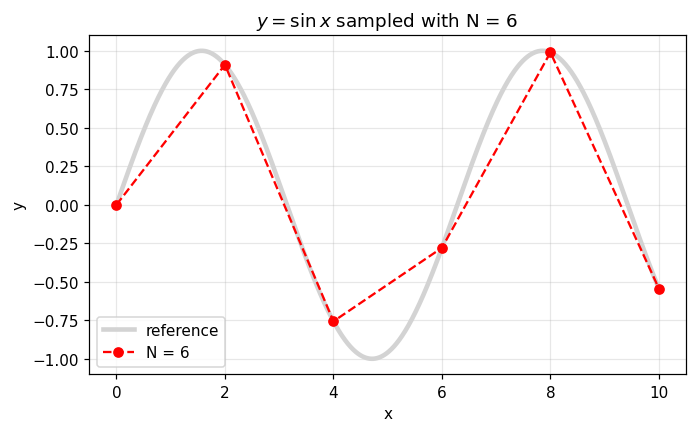

In [ ]:
# ข้อ 3: เขียนโค้ดของคุณที่นี่

### ข้อ 4 — เขียนโค้ดให้ได้กราฟเหมือนรูป B
- $\sin x$ (เส้นทึบ) และ $\cos x$ (เส้นประ) ในช่วง $[0, 2\pi]$ ใช้ 100 จุด
- มีเส้นแนวนอน $y = 0$ และแกน x แสดงค่าเป็นพหุคูณของ $\pi/2$

**คำใบ้:** `plt.axhline`, `plt.xticks(ตำแหน่ง, ป้ายชื่อ)`, `plt.xlim`


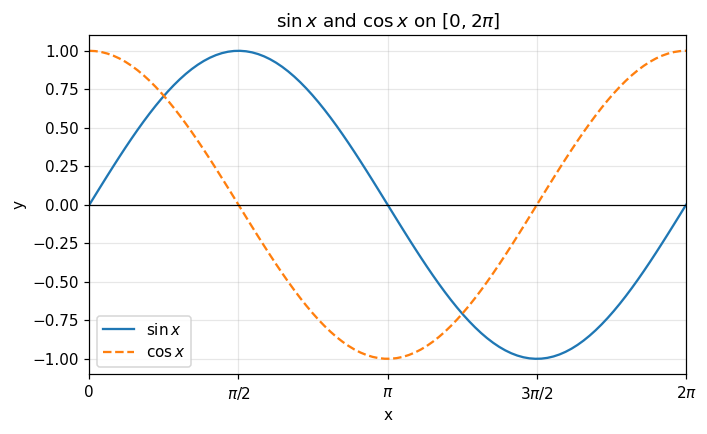

In [ ]:
# ข้อ 4: เขียนโค้ดของคุณที่นี่

### ข้อ 5 — การสั่นแบบหน่วง: เขียนโค้ดให้ได้กราฟเหมือนรูป C
$$x(t) = A\,e^{-\gamma t}\cos(\omega t)$$

| พารามิเตอร์ | ค่า |
|---|---|
| $A$ | 1.0 m |
| $\gamma$ | 0.2 s⁻¹ |
| $\omega$ | 3.0 rad/s |
| ช่วงเวลา | $0 \le t \le 20$ s, 500 จุด |

เส้นประสีเทาคือเส้นห่อหุ้ม (envelope) $\pm A e^{-\gamma t}$


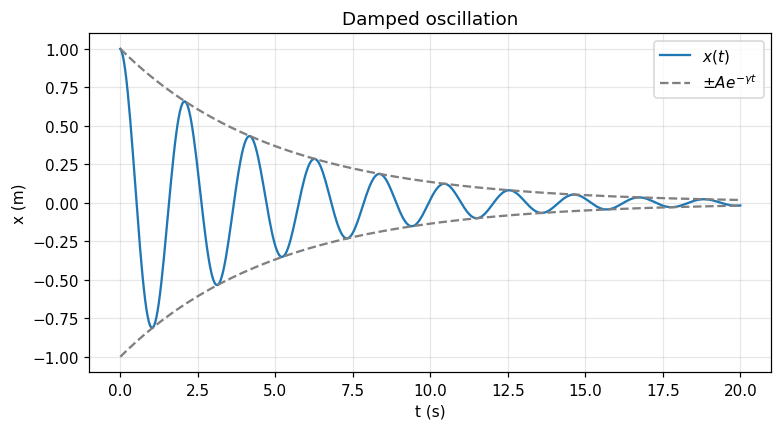

In [ ]:
# ข้อ 5: เขียนโค้ดของคุณที่นี่

### ข้อ 6 — กราฟย่อย (subplots): เขียนโค้ดให้ได้กราฟเหมือนรูป D
$y = x^2$ ในช่วง $[-2, 2]$ วาดด้วย N = 3, 5, 50 เรียงกัน 3 ช่อง ใช้แกน y ร่วมกัน

**คำถาม:** ที่ N = 3 ทำไมกราฟพาราโบลาจึงดูเหมือนตัว "V"? (ตอบในเซลล์ markdown)

**คำใบ้:** `fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)`


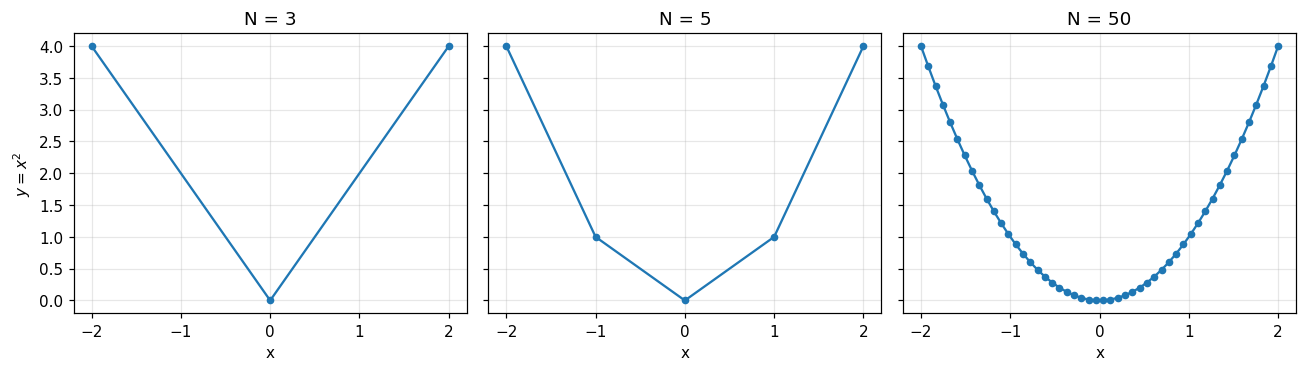

In [ ]:
# ข้อ 6: เขียนโค้ดของคุณที่นี่

**ข้อ 6 คำตอบ:** _(ดับเบิลคลิกเพื่อพิมพ์คำตอบ)_

### ข้อ 7 — กราฟที่ "หลอกตา"
รูป E เป็นกราฟของ $y = \sin(5x)$ ที่ใช้ N = 10 ในช่วง $[0, 10]$

| ส่วน | งาน |
|---|---|
| (ก) | เขียนโค้ดสร้างรูป E |
| (ข) | กราฟนี้ดูเหมือน $\sin(5x)$ หรือไม่? อธิบายโดยเปรียบเทียบคาบ $T = 2\pi/5$ กับ Δx |
| (ค) | หา N ที่น้อยที่สุดที่ทำให้กราฟดูเรียบและถูกต้อง แล้ววาดซ้อนกับรูปเดิม |


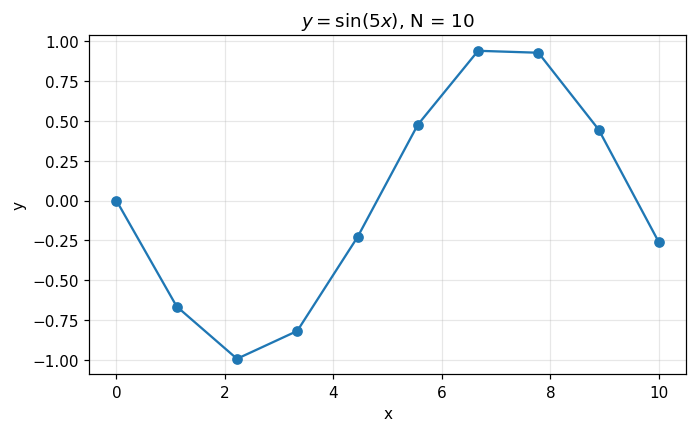

In [ ]:
# ข้อ 7 (ก): เขียนโค้ดของคุณที่นี่

**ข้อ 7 (ข) คำตอบ:** _(ดับเบิลคลิกเพื่อพิมพ์คำตอบ)_

In [ ]:
# ข้อ 7 (ค): เขียนโค้ดของคุณที่นี่

### ข้อ 8 (ท้าทาย) — ความคลาดเคลื่อนของการลากเส้นตรง: สร้างรูป F
matplotlib ลาก **เส้นตรง** ระหว่างจุด จึงมีความคลาดเคลื่อนจากฟังก์ชันจริง วัดได้โดย

1. สร้างจุดละเอียด `x_fine = np.linspace(0, 10, 5001)`
2. สำหรับ N = 5, 10, 20, 50, 100, 200 คำนวณค่าบนเส้นตรงด้วย `np.interp(x_fine, x, np.sin(x))`
3. หาค่าคลาดเคลื่อนสูงสุด $\max|\sin x - y_{\text{line}}|$
4. วาดด้วย `plt.loglog` เทียบกับทฤษฎี $E \approx \Delta x^2/8$ (เส้นประ)

**คำถาม:** ถ้าเพิ่ม N เป็น 2 เท่า ความคลาดเคลื่อนลดลงกี่เท่า? ดูจากความชันของเส้นใน log–log


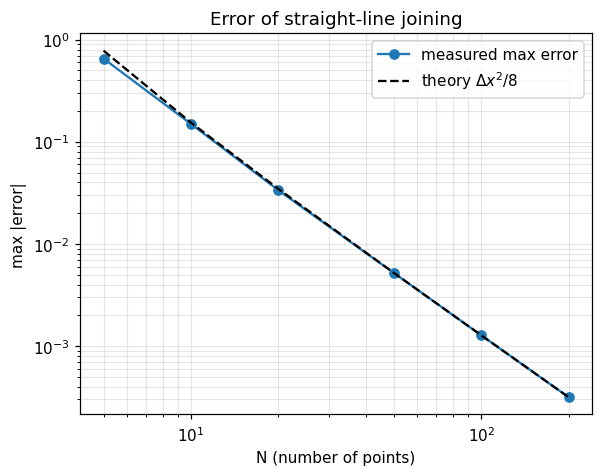

In [ ]:
# ข้อ 8: เขียนโค้ดของคุณที่นี่

**ข้อ 8 คำตอบ:** _(ดับเบิลคลิกเพื่อพิมพ์คำตอบ)_